# Warmup visualization

**Purpose:** Purpose of this notebook is to determine if there is a warm-up phase in AWS Lambdas.

**Definition warm-up phase:** A warm-up phase is defined as a time period where the performance of the system is below the operational phase.

**Operational phase:** The time period following the warm-up phase.

**Evaluation:** The evaluation is based on latency tests (GET/PUT requests from Lambda to S3). We determine that there is a warm-up phase, if there is a drop after some time.


### Importing the first dataset

The first dataset is a latency test, which measures the time synchronous GET requests to S3 needed to complete. The test is requesting an object of **size** 1 KB. The **duration** of the test is 30 seconds and the **lambda size** is 3009 MB. 

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# settings
%matplotlib inline

# import data
df = pd.read_csv("latency1KiBGet30Sec3008LambdaSize.csv")

### importing sample data
With a first look at some sample data, it does not look like the performance changes a lot

In [16]:
# print data
print("dataframe has {} rows".format(df["id"].size))
df[:]

dataframe has 2223 rows


,id,time_get_in_micro_sec
0,1,44087
1,2,8948
2,3,11933
3,4,13607
4,5,11829
...,...,...
2218,2219,10132
2219,2220,11763
2220,2221,17113
2221,2222,10850


### A first look at the data

Looking at the data, we see that there are a couple of outlyiers. Most of the request seem to finish before 100ms though (y-axes is in microseconds).

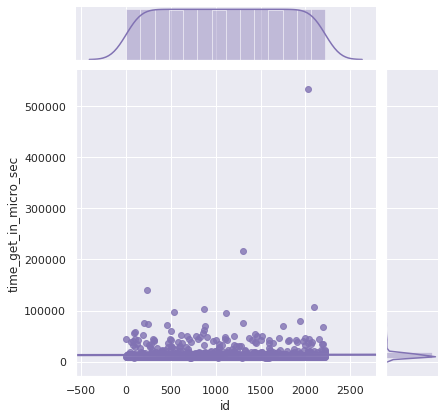

In [14]:
sns.set(style="darkgrid")
tips = sns.jointplot("id", "time_in_micro_sec", data=df, kind="reg", color="m")

### Closer looks at the data

Looks like there is not much of a correlation between the id (time) and the latency (at least in the first 30 seconds).

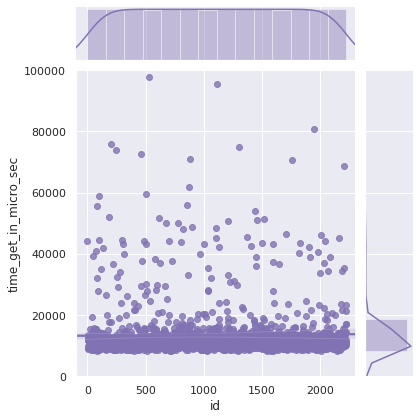

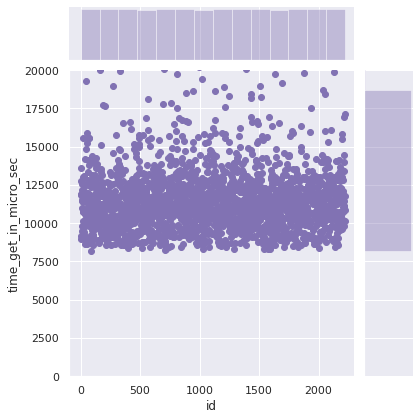

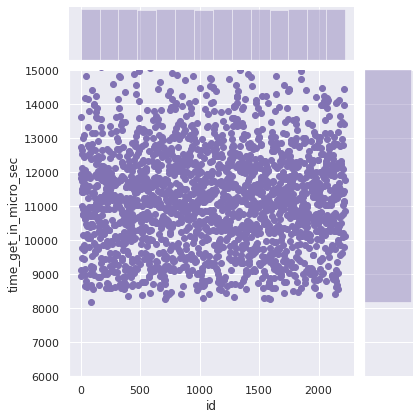

In [35]:
tips = sns.jointplot("id", "time_in_micro_sec", data=df, kind="reg", color="m", xlim=(-100,2300), ylim=(-10,100000))
tips = sns.jointplot("id", "time_in_micro_sec", data=df, kind="scatter", color="m", xlim=(-100,2300), ylim=(-10,20000))
tips = sns.jointplot("id", "time_in_micro_sec", data=df, kind="scatter", color="m", xlim=(-100,2300), ylim=(6000,15000))


### Is there any coreletion at all?

**Result:** I am not a statistics-guy, but this does not look like much of a relation to me. Also the corelations are positive. My understanding is that there should be a negative correlation if there is such a thing as a warm-up phase.

In [2]:
import numpy as np
from scipy.stats import pearsonr
from scipy.stats import spearmanr

# covariance. Kindof hard to interpret...
print("covariance is")
print(np.cov(df["id"],df["time_in_micro_sec"]))

# Pearson’s Correlation. Does not look like there is much of a correlation
corr, _ = pearsonr(df["id"],df["time_in_micro_sec"])
print("Pearson’s correlation is {}".format(corr))

# Spearman. Let`s check if there is a non-linear relation
corr, _ = spearmanr(df["id"],df["time_in_micro_sec"])
print('Spearmans correlation: %.3f' % corr)

covariance is


NameError: name 'df' is not defined

### Let's look at the other datasets and calculate the same measurements
**Notion:** The information about the experiment is "encoded" in the file name. The file name **latency1KiBPut30Sec3008LambdaSize.csv** means that an object of **size** 1KB (1024 Bytes) was requested, the **Lambda size** was 3008 MB, it was a write **operation** (HTTP PUT) and the **experiment** took 30 seconds

In [5]:
def load_ds(csv_name):
    print("loading csv with name {}".format(csv_name))
    return pd.read_csv(csv_name)
    

def print_statistics(csv):
    df = load_ds(csv)
    # covariance. Kindof hard to interpret...
    print("covariance is")
    print(np.cov(df["id"],df["time_in_micro_sec"]))

    # Pearson’s Correlation. Does not look like there is much of a correlation
    corr, _ = pearsonr(df["id"],df["time_in_micro_sec"])
    print("Pearson’s correlation is {}".format(corr))

    # Spearman. Let`s check if there is a non-linear relation
    corr, _ = spearmanr(df["id"],df["time_in_micro_sec"])
    print('Spearmans correlation: %.3f' % corr)
    
files = ["latency1KiBGet30Sec3008LambdaSize.csv", "latency1KiBPut30Sec3008LambdaSize.csv", "latency256KiBGet30Sec3008LambdaSize.csv", "latency256KiBPut30Sec3008LambdaSize.csv", "latency100MiBGet30Sec3008LambdaSize.csv", "latency100MiBPut30Sec3008LambdaSize.csv"]
for file in files:
    print_statistics(file)
    print("")

loading csv with name latency1KiBGet30Sec3008LambdaSize.csv
covariance is
[[4.11996000e+05 8.92439514e+04]
 [8.92439514e+04 2.12170950e+08]]
Pearson’s correlation is 0.009545294476873217
Spearmans correlation: 0.005

loading csv with name latency1KiBPut30Sec3008LambdaSize.csv
covariance is
[[ 2.78885000e+04 -2.59590339e+05]
 [-2.59590339e+05  1.41621712e+09]]
Pearson’s correlation is -0.041305798968865534
Spearmans correlation: -0.090

loading csv with name latency256KiBGet30Sec3008LambdaSize.csv
covariance is
[[ 2.55938000e+05 -5.77015551e+04]
 [-5.77015551e+04  1.92525767e+08]]
Pearson’s correlation is -0.008220073503703485
Spearmans correlation: 0.067

loading csv with name latency256KiBPut30Sec3008LambdaSize.csv
covariance is
[[ 6.98416667e+03 -2.31033069e+05]
 [-2.31033069e+05  8.80224964e+09]]
Pearson’s correlation is -0.029465920309402018
Spearmans correlation: -0.020

loading csv with name latency100MiBGet30Sec3008LambdaSize.csv
covariance is
[[6.00000000e+00 2.34452357e+05]
 [

### Further investigation
latency1KiBPut30Sec3008LambdaSize.csv looks interesting. Maybe there is a warm-up phase that is only notable if there are operations that take longer?

**Result:** Still does not look like much of a correlation to me

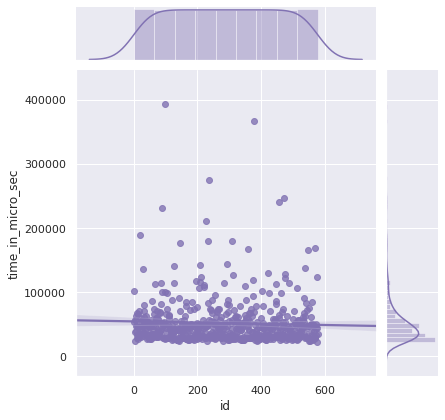

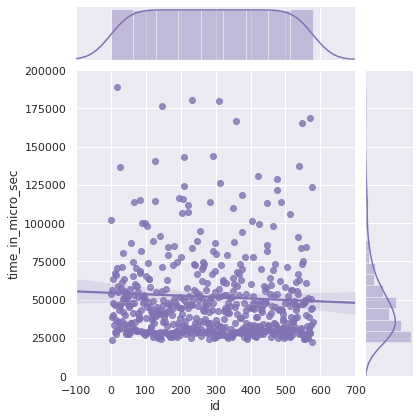

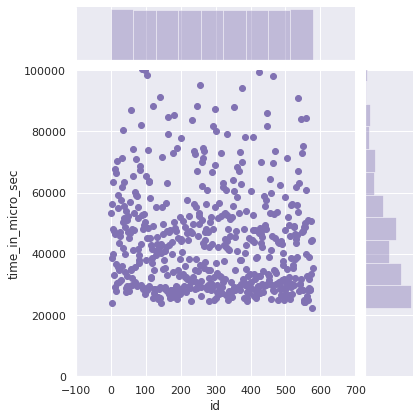

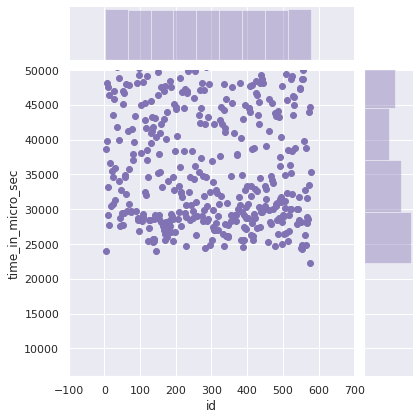

In [50]:
df = pd.read_csv("latency1KiBPut30Sec3008LambdaSize.csv")
tips = sns.jointplot("id", "time_in_micro_sec", data=df, kind="reg", color="m")
tips = sns.jointplot("id", "time_in_micro_sec", data=df, kind="reg", color="m", xlim=(-100,700), ylim=(-10,200000))
tips = sns.jointplot("id", "time_in_micro_sec", data=df, kind="scatter", color="m", xlim=(-100,700), ylim=(-10,100000))
tips = sns.jointplot("id", "time_in_micro_sec", data=df, kind="scatter", color="m", xlim=(-100,700), ylim=(6000,50000))


### Further investigation
Let`s also look at latency100MiBGet30Sec3008LambdaSize.csv
This does not look like a warm-up phase, but like random gitter across very few data-poits to me...

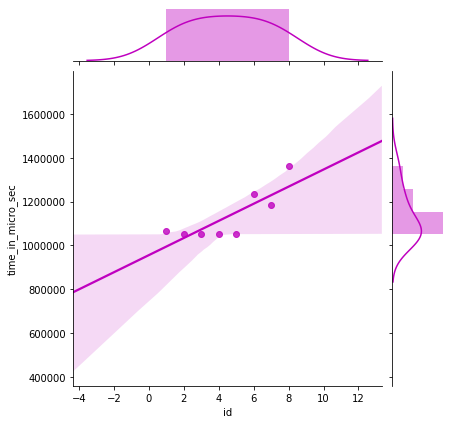

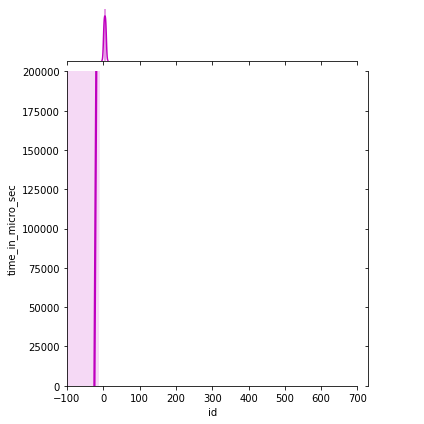

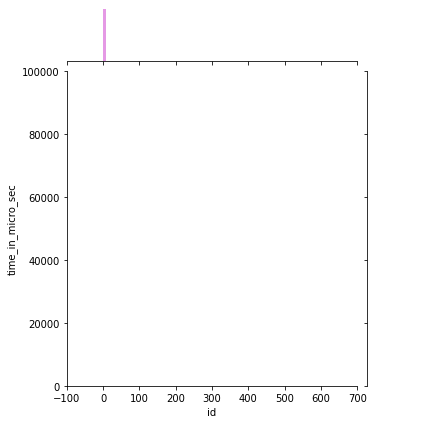

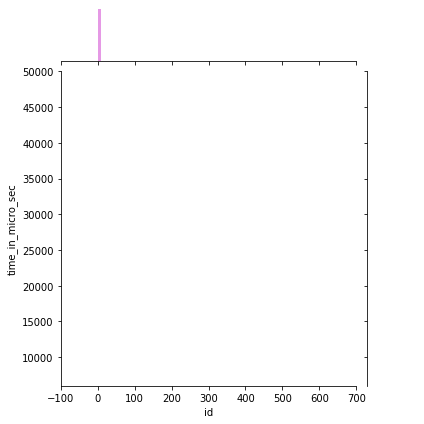

In [6]:
df = pd.read_csv("latency100MiBGet30Sec3008LambdaSize.csv")
tips = sns.jointplot("id", "time_in_micro_sec", data=df, kind="reg", color="m")
tips = sns.jointplot("id", "time_in_micro_sec", data=df, kind="reg", color="m", xlim=(-100,700), ylim=(-10,200000))
tips = sns.jointplot("id", "time_in_micro_sec", data=df, kind="scatter", color="m", xlim=(-100,700), ylim=(-10,100000))
tips = sns.jointplot("id", "time_in_micro_sec", data=df, kind="scatter", color="m", xlim=(-100,700), ylim=(6000,50000))
